In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo 

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

class TimeSeriesDataset(Dataset):
    """Dataset PyTorch genérico para séries temporais janeladas.
    Aceita y com shape (N,) para saída univariada ou (N, H) para saída multivariada.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)
        self.y = y_t.unsqueeze(1) if y_t.dim() == 1 else y_t  # (N,1) ou (N,H)

    def __getitem__(self, i): return self.X[i], self.y[i]
    def __len__(self):        return len(self.X)

class MLP(nn.Module):
    """
    Rede Neural MLP configurável.
    Versão relativamente diferente ao apresentado em sala de aula. Neste, é feito uso
    artefato de um modelo "sequential", simplificando a implementação.
    Parâmetros
    ----------
    n_input      : int  — dimensão da entrada
    hidden_layers: list — neurônios por camada oculta, ex: [64, 32]
    n_output     : int  — dimensão da saída (1 para MISO; n_vars para MIMO)
    activation   : str  — 'relu', 'sigmoid' ou 'tanh'
    """
    _acts = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh}

    def __init__(self, n_input=10, hidden_layers=[64], n_output=1, activation='relu'):
        super().__init__()
        act_cls = self._acts[activation]
        layers, in_dim = [], n_input
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), act_cls()]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_output))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)


def make_windows_univariate(series, window_size, horizon=1):
    """
    Janela deslizante para série 1-D (abordagem univariada).

    Retorna
    -------
    X : (N, window_size)
    y : (N,) se horizon==1  |  (N, horizon) se horizon>1
    """
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        chunk = series[i + window_size : i + window_size + horizon]
        y.append(chunk[0] if horizon == 1 else chunk)
    return np.array(X), np.array(y)


def make_windows_multivariate(df_scaled, target_col, feature_cols,
                               window_size, horizon=1, mode='MISO'):
    """
    Janela deslizante para dados multivariados.

    Parâmetros
    ----------
    df_scaled   : pd.DataFrame normalizado
    target_col  : str   — coluna alvo
    feature_cols: list  — colunas usadas como features (inclui target_col)
    window_size : int
    horizon     : int
    mode        : 'MISO' — saída = próximo(s) valor(es) do target_col
                  'MIMO' — saída = próximos valores de TODAS as target_cols

    Retorna
    -------
    X : (N, window_size * n_features)
    y : (N,) ou (N, horizon)          para MISO
        (N, n_features)               para MIMO com horizon==1
        (N, horizon * n_features)     para MIMO com horizon>1
    """
    data   = df_scaled[feature_cols].values     # (T, F)
    target = df_scaled[target_col].values       # (T,)
    n_feat = len(feature_cols)
    X, y   = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size].ravel())          # flatten → (W*F,)
        if mode == 'MISO':
            chunk = target[i + window_size : i + window_size + horizon]
            y.append(chunk[0] if horizon == 1 else chunk)
        else:  # MIMO
            chunk = data[i + window_size : i + window_size + horizon]  # (H, F)
            y.append(chunk.ravel())                          # (H*F,)

    return np.array(X), np.array(y)


def train_with_val(model, train_loader, val_loader, epochs=300, lr=1e-3, patience=200):
    opt, loss_fn = torch.optim.Adam(model.parameters(), lr=lr), nn.MSELoss()
    best_val, best_state, wait = float('inf'), None, 0
    hist = {'train': [], 'val': []}
    for ep in range(1, epochs + 1):
        model.train(); tr = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward(); opt.step()
            tr += loss.item()
        model.eval(); vl = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                vl += loss_fn(model(Xb), yb).item()
        tr, vl = tr / len(train_loader), vl / len(val_loader)
        hist['train'].append(tr); hist['val'].append(vl)
        if vl < best_val:
            best_val, wait = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop @ epoch {ep} | best val {best_val:.6f}"); break
        if ep % 20 == 0:
            print(f"Ep {ep:3d} | train {tr:.6f} | val {vl:.6f}")
    model.load_state_dict(best_state)
    return hist


def recursive_forecast_univariate(model, X_seed, horizon):
    """
    Previsão recursiva para modelo one-step univariado.
    X_seed : np.ndarray (window_size,)
    """
    model.eval()
    window, preds = X_seed.copy(), []
    with torch.no_grad():
        for _ in range(horizon):
            x_t = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()
            preds.append(y_hat)
            window = np.roll(window, -1)
            window[-1] = y_hat
    return np.array(preds)


def recursive_forecast_multivariate(model, X_seed, horizon, window_size, n_features):
    """
    Previsão recursiva para modelo MISO multivariado.
    X_seed : np.ndarray (window_size * n_features,)  — janela inicial achatada
    Retorna apenas as previsões do target (primeira feature por convenção).
    """
    model.eval()
    window = X_seed.reshape(window_size, n_features).copy()  # (W, F)
    preds  = []
    with torch.no_grad():
        for _ in range(horizon):
            x_t   = torch.tensor(window.ravel(), dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()          # previsão do target
            preds.append(y_hat)
            # Desliza a janela: descarta t mais antigo, acrescenta t+1
            new_row        = window[-1].copy()  # repete as exógenas do último passo
            new_row[0]     = y_hat              # atualiza o target (posição 0 por convenção)
            window         = np.vstack([window[1:], new_row])
    return np.array(preds)

def rrse_naive(y_true, y_pred):
    """
    RRSE com baseline naive: y_{t+1} ≈ y_t

    Parâmetros:
    - y_true: array com valores reais (y_{t+1})
    - y_pred: array com previsões do modelo (ŷ_{t+1})

    Retorna:
    - rrse (float)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # garante alinhamento temporal
    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    num = np.sum((y_true - y_pred) ** 2)

    # denominador: erro do naive (y_t)
    # precisamos de y_t → shift de y_true
    y_t = y_true[:-1]
    y_t1 = y_true[1:]

    denom = np.sum((y_t1 - y_t) ** 2)

    if denom == 0:
        return np.nan  # ou np.inf dependendo do caso

    return np.sqrt(num / denom)

def evaluate(y_true, y_pred, label='Modelo', scaler=None, target_idx=0):
    """
    Calcula e exibe MSE, RMSE, MAE e SSE.
    Se scaler não for None, desnormaliza antes de calcular.
    target_idx: coluna do target caso y seja multivariado.
    """
    yt, yp = np.array(y_true).ravel(), np.array(y_pred).ravel()
    if scaler is not None:
        # Desnormaliza somente a coluna do target
        def inv(v):
            tmp = np.zeros((len(v), scaler.n_features_in_))
            tmp[:, target_idx] = v
            return scaler.inverse_transform(tmp)[:, target_idx]
        yt, yp = inv(yt), inv(yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp)
    rrse = rrse_naive(yt, yp)
    sse  = np.sum((yt - yp) ** 2)
    print(f"[{label}]  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  SSE={sse:.2f}  MAPE={mape:.2f}  RRSE*:{rrse:.2f}")
    return mse, rmse, mae, sse
    
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

TARGET_COLS = ['vehicle_local_position.vx', 'vehicle_local_position.vy', 'vehicle_local_position.vz']
FEATURES_COLS = ['actuator_motors.control.00', 'actuator_motors.control.01', 'actuator_motors.control.02', 'actuator_motors.control.03',
                 'vehicle_angular_velocity.xyz.00', 'vehicle_angular_velocity.xyz.01', 'vehicle_angular_velocity.xyz.02',
                 'vehicle_attitude.q.00', 'vehicle_attitude.q.01', 'vehicle_attitude.q.02', 'vehicle_attitude.q.03',
                 'vehicle_local_position.vx', 'vehicle_local_position.vy', 'vehicle_local_position.vz']  


dataset = pd.read_csv("/home/wenis/Mestrado/2026.1/Dev_NN_DS/data_flights/csv/0.csv")

Using device: cuda


Datasets 9 e 10 serão separados para o teste.

Dentro dos outros datasets, em cada arquivo, 70% será separado para treinamento e 30% para validação.

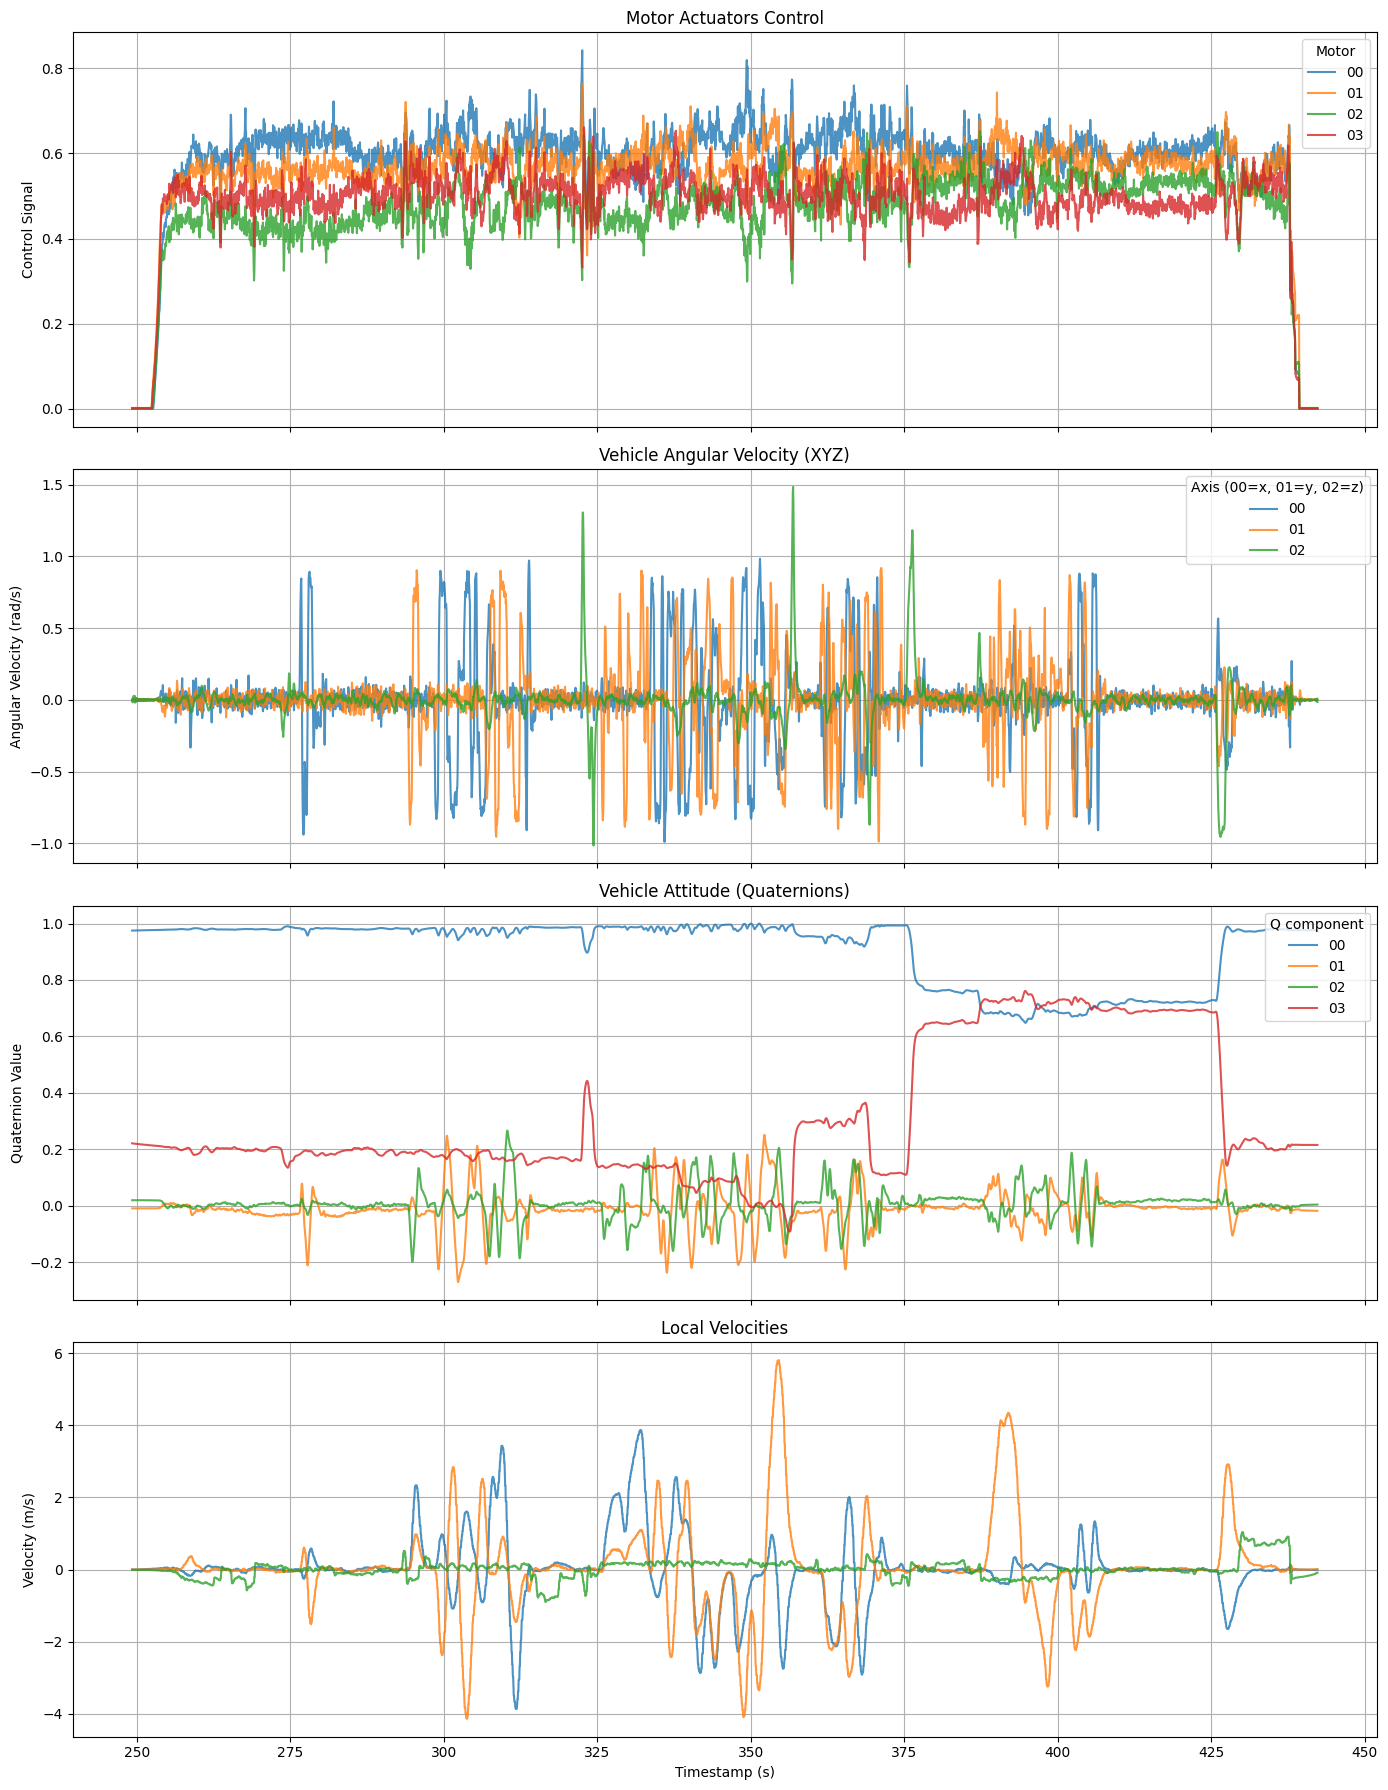

In [ ]:
import matplotlib.pyplot as plt
# talvez retirar o 8
data = pd.read_csv("/home/wenis/Mestrado/2026.1/Dev_NN_DS/data_flights/csv/10.csv")

# Create a figure with 5 subplots sharing the x-axis
fig, axs = plt.subplots(4, 1, figsize=(14, 18), sharex=True)

# Convert timestamp to a numpy array once to reuse it
t_vals = data['timestamp_s'].to_numpy()

# ---------------------------------------------------------
# 1. Motor Actuators Control
# ---------------------------------------------------------
motors = ['actuator_motors.control.00', 'actuator_motors.control.01', 
          'actuator_motors.control.02', 'actuator_motors.control.03']

for m in motors:
    # Adding .to_numpy() to the y-axis data
    axs[0].plot(t_vals, data[m].to_numpy(), label=m[-2:], alpha=0.8)

axs[0].set_title('Motor Actuators Control')
axs[0].set_ylabel('Control Signal')
axs[0].legend(loc='upper right', title="Motor")
axs[0].grid(True)

# ---------------------------------------------------------
# 2. Vehicle Angular Velocity
# ---------------------------------------------------------
ang_vels = ['vehicle_angular_velocity.xyz.00', 'vehicle_angular_velocity.xyz.01', 
            'vehicle_angular_velocity.xyz.02']

for av in ang_vels:
    axs[1].plot(t_vals, data[av].to_numpy(), label=av[-2:], alpha=0.8)

axs[1].set_title('Vehicle Angular Velocity (XYZ)')
axs[1].set_ylabel('Angular Velocity (rad/s)')
axs[1].legend(loc='upper right', title="Axis (00=x, 01=y, 02=z)")
axs[1].grid(True)

# ---------------------------------------------------------
# 3. Vehicle Attitude (Quaternions)
# ---------------------------------------------------------
attitude = ['vehicle_attitude.q.00', 'vehicle_attitude.q.01', 
            'vehicle_attitude.q.02', 'vehicle_attitude.q.03']

for q in attitude:
    axs[2].plot(t_vals, data[q].to_numpy(), label=q[-2:], alpha=0.8)

axs[2].set_title('Vehicle Attitude (Quaternions)')
axs[2].set_ylabel('Quaternion Value')
axs[2].legend(loc='upper right', title="Q component")
axs[2].grid(True)

# ---------------------------------------------------------
# 4. Local Accelerations and Velocities
# ---------------------------------------------------------

vels = ['vehicle_local_position.vx', 'vehicle_local_position.vy', 'vehicle_local_position.vz']

# Plot velocities on the primary (left) y-axis
for v in vels:
    axs[3].plot(t_vals, data[v].to_numpy(), label=f"Vel {v[-2:]}", linestyle='-', alpha=0.8)
axs[3].set_ylabel('Velocity (m/s)')
axs[3].set_xlabel('Timestamp (s)')


# Combine legends from both primary and twin axes
lines_1, labels_1 = axs[3].get_legend_handles_labels()

axs[3].set_title('Local Velocities')
axs[3].grid(True)


# ---------------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

In [19]:
datasets = []
for i in range(11):
    dataset = pd.read_csv(f"/home/wenis/Mestrado/2026.1/Dev_NN_DS/data_flights/csv/{i}.csv")
    dataset = dataset[FEATURES_COLS]  
    print(f"Dataset {i} shape: {dataset.shape}")
    datasets.append(dataset)

datasets[10].info()
print("test")

for i, dataset in enumerate(datasets):
    if dataset.isnull().sum().sum() > 0:
        print(f"Dataset {i} has missing values:")
    

Dataset 0 shape: (1140, 14)
Dataset 1 shape: (9493, 14)
Dataset 2 shape: (927, 14)
Dataset 3 shape: (1120, 14)
Dataset 4 shape: (1456, 14)
Dataset 5 shape: (3862, 14)
Dataset 6 shape: (950, 14)
Dataset 7 shape: (696, 14)
Dataset 8 shape: (9267, 14)
Dataset 9 shape: (16893, 14)
Dataset 10 shape: (7449, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7449 entries, 0 to 7448
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   actuator_motors.control.00       7449 non-null   float64
 1   actuator_motors.control.01       7449 non-null   float64
 2   actuator_motors.control.02       7449 non-null   float64
 3   actuator_motors.control.03       7449 non-null   float64
 4   vehicle_angular_velocity.xyz.00  7449 non-null   float64
 5   vehicle_angular_velocity.xyz.01  7449 non-null   float64
 6   vehicle_angular_velocity.xyz.02  7449 non-null   float64
 7   vehicle_attitude.q.00  

# Análise Inicial

Primeiro, vamos analisar a apenas as saídas de velocidade angular

In [8]:
TARGET_COLS = ['vehicle_local_position.vx', 'vehicle_local_position.vy', 'vehicle_local_position.vz']
FEATURES_COLS = ['actuator_motors.control.00', 'actuator_motors.control.01', 'actuator_motors.control.02', 'actuator_motors.control.03',
                 'vehicle_angular_velocity.xyz.00', 'vehicle_angular_velocity.xyz.01', 'vehicle_angular_velocity.xyz.02',
                 'vehicle_attitude.q.00', 'vehicle_attitude.q.01', 'vehicle_attitude.q.02', 'vehicle_attitude.q.03',
                 'vehicle_local_position.vx', 'vehicle_local_position.vy', 'vehicle_local_position.vz']  

In [30]:
VALIDATION_SPLIT = 0.3
WINDOW_SIZE = 10

ANG_VEL_COLS = ['vehicle_angular_velocity.xyz.00',
                'vehicle_angular_velocity.xyz.01',
                'vehicle_angular_velocity.xyz.02']
LIN_VEL_COLS = ['vehicle_local_position.vx',
                'vehicle_local_position.vy',
                'vehicle_local_position.vz']


train_dfs, val_dfs, test_dfs = [], [], []

for i, df in enumerate(datasets):
    if i == 5 or i == 10:                                   # 9, 10 -> test
        test_dfs.append(df.copy())
    else:
        cut = int(len(df) * (1 - VALIDATION_SPLIT))
        train_dfs.append(df.iloc[:cut].copy())  # 70%
        val_dfs.append(df.iloc[cut:].copy())    # 30%

train_pool = pd.concat(train_dfs, axis=0, ignore_index=True)

scaler = MinMaxScaler()
scaler_ang = scaler.fit(train_pool[ANG_VEL_COLS])
scaler_lin = scaler.fit(train_pool[LIN_VEL_COLS])

def apply_scaling(df):
    df = df.copy()
    df[ANG_VEL_COLS] = scaler_ang.transform(df[ANG_VEL_COLS].values)
    df[LIN_VEL_COLS] = scaler_lin.transform(df[LIN_VEL_COLS].values)
    return df

train_dfs = [apply_scaling(d) for d in train_dfs]
val_dfs   = [apply_scaling(d) for d in val_dfs]
test_dfs  = [apply_scaling(d) for d in test_dfs]

def build_xy(df_list):
    Xs, ys = [], []
    for df in df_list:
        X, y = make_windows_multivariate(df, TARGET_COLS, FEATURES_COLS,
                                          WINDOW_SIZE, horizon=1, mode='MISO')
        Xs.append(X); ys.append(y)
    return np.concatenate(Xs), np.concatenate(ys)

X_train, y_train = build_xy(train_dfs)
X_val,   y_val   = build_xy(val_dfs)
X_test, y_test  = build_xy(test_dfs)

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape} | y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape} | y_test shape: {y_test.shape}")

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=64, shuffle=False)
val_loader   = DataLoader(TimeSeriesDataset(X_val,   y_val),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TimeSeriesDataset(X_test,  y_test),  batch_size=64, shuffle=False)

model = MLP(n_input=WINDOW_SIZE*len(FEATURES_COLS), hidden_layers=[128, 64],
            n_output=3, activation='relu').to(device)


X_train shape: (29267, 140) | y_train shape: (29267, 3)
X_val shape: (12495, 140) | y_val shape: (12495, 3)
X_test shape: (11291, 140) | y_test shape: (11291, 3)


In [35]:
history = train_with_val(model, train_loader, val_loader, epochs=500, lr=1e-3)

Ep  20 | train 0.000480 | val 0.000803
Ep  40 | train 0.000657 | val 0.001099
Ep  60 | train 0.000533 | val 0.000780
Ep  80 | train 0.000543 | val 0.000950
Ep 100 | train 0.000360 | val 0.001010
Ep 120 | train 0.000442 | val 0.000998
Ep 140 | train 0.000346 | val 0.000704
Ep 160 | train 0.000440 | val 0.000930
Ep 180 | train 0.000325 | val 0.000686
Ep 200 | train 0.000306 | val 0.000740
Ep 220 | train 0.000324 | val 0.001038
Ep 240 | train 0.000269 | val 0.000580
Ep 260 | train 0.000235 | val 0.000449
Ep 280 | train 0.000224 | val 0.000321
Ep 300 | train 0.000272 | val 0.000404
Ep 320 | train 0.000229 | val 0.000783
Ep 340 | train 0.000194 | val 0.000336
Ep 360 | train 0.000300 | val 0.000586
Ep 380 | train 0.000221 | val 0.000577
Ep 400 | train 0.000288 | val 0.000464
Ep 420 | train 0.000203 | val 0.000373
Ep 440 | train 0.000292 | val 0.000465
Ep 460 | train 0.000237 | val 0.000387
Ep 480 | train 0.000150 | val 0.000312
Ep 500 | train 0.000220 | val 0.000303


[Test vx]  MSE=0.0208  RMSE=0.1444  MAE=0.1259  SSE=235.27  MAPE=11.03  RRSE*:3.18
[Test vy]  MSE=0.0146  RMSE=0.1209  MAE=0.0870  SSE=164.99  MAPE=11.59  RRSE*:2.26
[Test vz]  MSE=0.0511  RMSE=0.2260  MAE=0.1427  SSE=576.46  MAPE=8.16  RRSE*:9.00


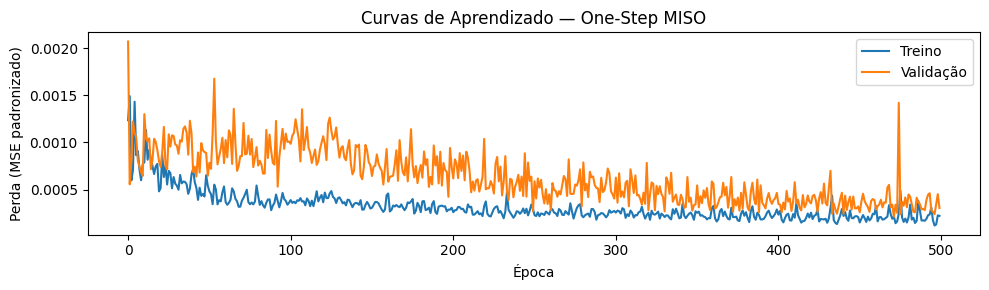

In [39]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        xb = torch.tensor(X, dtype=torch.float32).to(device)
        return model(xb).cpu().numpy()          # (N, 3), standardized space

# ---- Metrics in physical units (m/s) ----
yp_test = predict(model, X_test)
yt_real = scaler_lin.inverse_transform(y_test)   # (N, 3)
yp_real = scaler_lin.inverse_transform(yp_test)  # (N, 3)

for j, name in enumerate(['vx', 'vy', 'vz']):
    evaluate(yt_real[:, j], yp_real[:, j], label=f'Test {name}', scaler=None)


# Per-flight test windows (clean plots, no concatenation discontinuity)
test_xy = [make_windows_multivariate(df, TARGET_COLS, FEATURES_COLS,
                                     WINDOW_SIZE, horizon=1, mode='MISO')
           for df in test_dfs]

X_te0, y_te0 = test_xy[0]                         # first test flight
yt0 = scaler_lin.inverse_transform(y_te0)         # (N, 3) m/s
yp0 = scaler_lin.inverse_transform(predict(model, X_te0))

plt.figure(figsize=(10, 3))
plt.plot(history['train'], label='Treino')
plt.plot(history['val'],   label='Validação')
plt.title('Curvas de Aprendizado — One-Step MISO')
plt.xlabel('Época'); plt.ylabel('Perda (MSE padronizado)')
plt.legend(); plt.tight_layout(); plt.show()

[Test flight 0 — vx]  MSE=0.0208  RMSE=0.1444  MAE=0.1259  SSE=235.27  MAPE=11.03  RRSE*:3.18
[Test flight 0 — vy]  MSE=0.0146  RMSE=0.1209  MAE=0.0870  SSE=164.99  MAPE=11.59  RRSE*:2.26
[Test flight 0 — vz]  MSE=0.0511  RMSE=0.2260  MAE=0.1427  SSE=576.46  MAPE=8.16  RRSE*:9.00


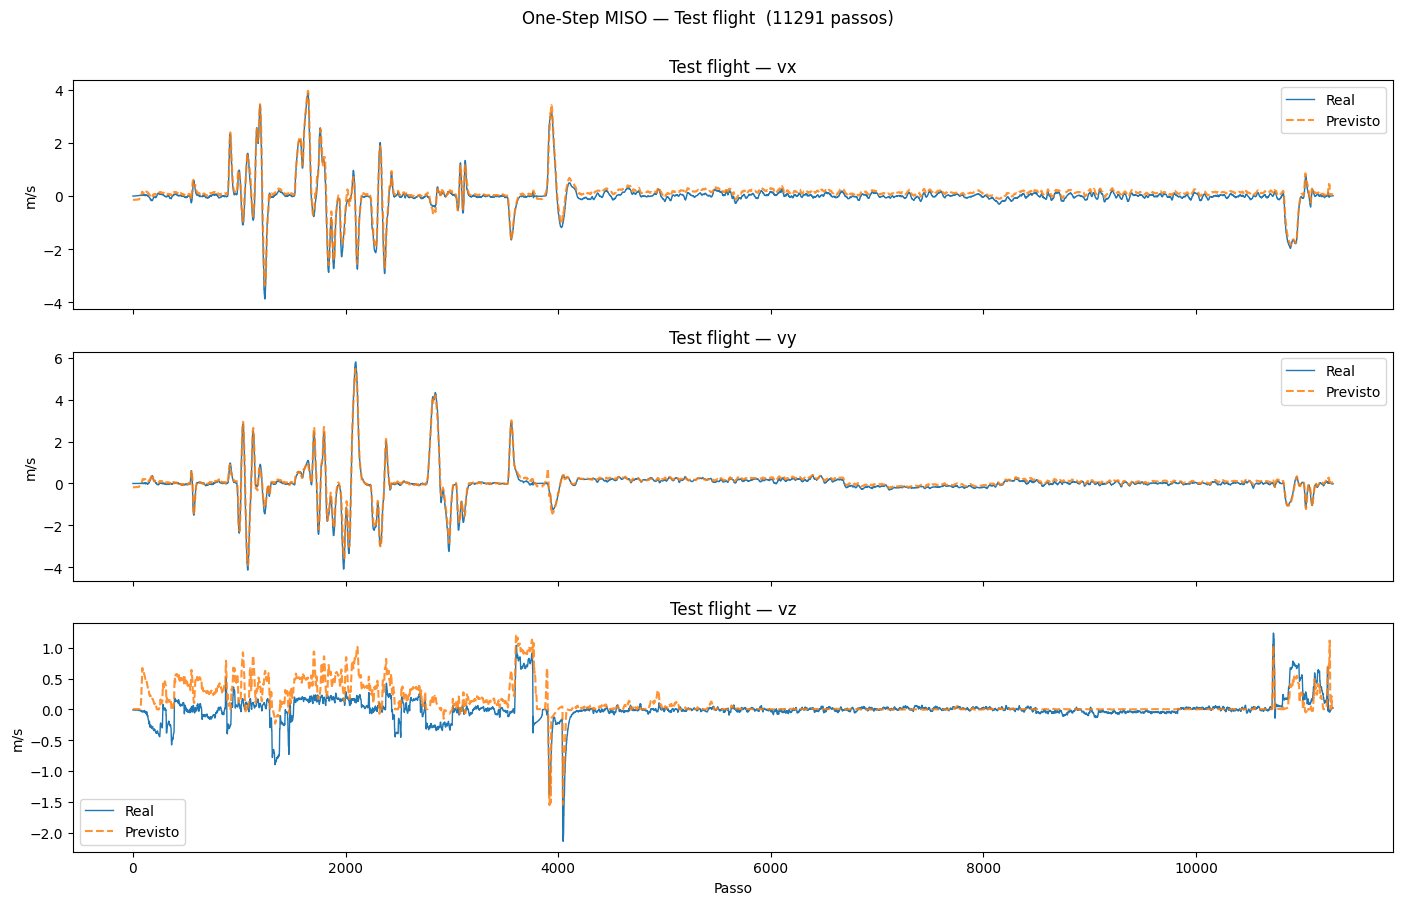

In [41]:
# Per-flight windows for both test flights (no concatenation discontinuity)


yt = scaler_lin.inverse_transform(y_test)                  # (N, 3) m/s
yp = scaler_lin.inverse_transform(predict(model, X_test))  # (N, 3) m/s

# metrics for this whole flight
for j, name in enumerate(['vx', 'vy', 'vz']):
    evaluate(yt[:, j], yp[:, j], label=f'Test flight {k} — {name}', scaler=None)

# plot the FULL flight (no length cap)
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for j, (ax, name) in enumerate(zip(axes, ['vx', 'vy', 'vz'])):
    ax.plot(yt[:, j], label='Real', linewidth=1.0)
    ax.plot(yp[:, j], label='Previsto', linestyle='--', alpha=0.85)
    ax.set_title(f'Test flight — {name}'); ax.set_ylabel('m/s'); ax.legend()
axes[-1].set_xlabel('Passo')
fig.suptitle(f'One-Step MISO — Test flight  ({len(yt)} passos)', y=1.001)
plt.tight_layout(); plt.show()